In [14]:
from datetime import datetime

from arcgis.gis import GIS
gis = GIS(profile="your_online_profile")

In [15]:
from arcgis.features.use_proximity import plan_routes

In [16]:
item = gis.content.get('9dd95559f5764830a39caf0cc9d176e5')

<Item title:"esri_office_employee_routing" type:Feature Layer Collection owner:demos_deldev>
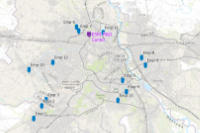

In [17]:
item

In [18]:
for lyr in item.layers:
    print(lyr.properties.name)

employee_residence
office_location


In [6]:
office_location = item.layers[1]
employee_residence = item.layers[0]

In [7]:
lyr = item.layers[0]

In [8]:
lyr

<FeatureLayer url:"https://services6.arcgis.com/SMX5BErCXLM7eDtY/arcgis/rest/services/esri_office_employee_routing/FeatureServer/0">

In [9]:
cloned = gis.content.clone_items([item])

In [10]:
cloned

[<Item title:"esri_office_employee_routing" type:Feature Layer Collection owner:demos_deldev>]

In [11]:
stops_lyr = cloned

<Item title:"esri_office_employee_routing" type:Feature Layer Collection owner:demos_deldev>
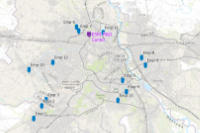

In [12]:
stops_lyr[0]

In [19]:
office = gis.content.get('9dd95559f5764830a39caf0cc9d176e5')#9dd95559f5764830a39caf0cc9d176e5

<Item title:"esri_office_employee_routing" type:Feature Layer Collection owner:demos_deldev>
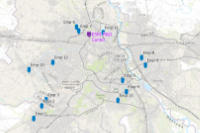

In [20]:
office

In [21]:
cloned = gis.content.clone_items([office])

In [22]:
starts_lyr = cloned

In [23]:
from datetime import datetime

In [24]:
datetime(2019, 6, 20, 6, 0)

datetime.datetime(2019, 6, 20, 6, 0)

In [27]:
route_count = 3
max_stpos_per_route = 4
route_start_time = datetime(2019, 6, 1, 6, 0)
route_count = 4


In [31]:
import arcgis.network as network
route_service = network.RouteLayer(gis.properties.helperServices.route.url, gis=gis)
travel_mode = [i['name'] for i in route_service.retrieve_travel_modes()['supportedTravelModes']]
travel_mode

['Driving Time',
 'Driving Distance',
 'Trucking Time',
 'Trucking Distance',
 'Walking Time',
 'Walking Distance',
 'Rural Driving Time',
 'Rural Driving Distance']

In [33]:
from datetime import datetime
test = plan_routes(stops_layer=employee_residence,
                   route_count=4,
                   max_stops_per_route=4,
                   route_start_time=datetime(2019, 6, 20, 6, 0),
                   start_layer=office_location,
                   start_layer_route_id_field='n_office',
                   return_to_start=False,
                   end_layer=office_location,
                   end_layer_route_id_field='n_office',
                   travel_mode='Driving Time',
                   stop_service_time=5,
                   include_route_layers=False,
                   output_name='test plan route' + str(datetime.now().microsecond))

Network elements with avoid-restrictions are traversed in the output (restriction attribute names: "Avoid Private Roads" "Through Traffic Prohibited" "Avoid Gates").


In [34]:
test

<Item title:"test plan route632101" type:Feature Layer Collection owner:demos_deldev>

In [35]:
test.delete()

True

In [ ]:
test = plan_routes(stops_layer=employee_residence,
                   route_count=4,
                   max_stops_per_route=4,
                   route_start_time=datetime(2019, 6, 20, 6, 0),
                   start_layer=office_location,
                   start_layer_route_id_field='n_office',
                   return_to_start=False,
                   end_layer=office_location,
                   end_layer_route_id_field='n_office',
                   travel_mode='Driving Time',
                   stop_service_time=5,
                   include_route_layers=False)

In [ ]:
test

In [ ]:
test = plan_routes(stops_layer=stops_lyr[0].layers[0],
                   route_count=3,
                   max_stops_per_route=4,
                   route_start_time=datetime(2019, 6, 20, 6, 0),
                   start_layer=starts_lyr[0].layers[0],
                   start_layer_route_id_field='n_office',
                   end_layer=starts_lyr[0].layers[0],
                   end_layer_route_id_field='n_office',
                   travel_mode='Driving',
                   stop_service_time=0,
                   include_route_layers=False,
                   output_name='test plan route' + str(datetime.now().microsecond))

In [ ]:
test.delete()